<a href="https://colab.research.google.com/github/pjastr-uwm/fakultet_io_2026/blob/main/lab04/lab04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Klasyczne reprezentacje wektorowe tekstu -- BoW i TF-IDF

W tym notatniku przeczwiczymy:

1. Budowe macierzy Bag-of-Words za pomoca `CountVectorizer`
2. Budowe macierzy TF-IDF za pomoca `TfidfVectorizer`
3. Interpretacje wynikow -- ktore cechy sa najwazniejsze i dlaczego
4. Wplyw parametrow (`ngram_range`, `min_df`, `max_features`) na rozmiar macierzy
5. Porownanie podobienstwa dokumentow (cosine similarity)


---
## 0. Import bibliotek

Google Colab ma domyslnie zainstalowane `scikit-learn`, `numpy`, `pandas` i `matplotlib`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

print("Wszystko gotowe!")

Wszystko gotowe!


---
## 1. Przyklad z omowieniem -- ogloszenia o prace

Ponizej mamy maly korpus 8 ogloszen o prace z branzy IT i marketingu.
Zbudujemy dla nich macierze BoW i TF-IDF, a nastepnie krok po kroku zinterpretujemy wyniki.

In [2]:
ogloszenia = [
    "Szukamy programisty Python z doswiadczeniem w analizie danych",         # D0 - IT/dane
    "Programista Java potrzebny do zespolu backendowego",                    # D1 - IT/backend
    "Analityk danych ze znajomoscia SQL i Python mile widziany",             # D2 - IT/dane
    "Specjalista SEO z doswiadczeniem w marketingu internetowym",            # D3 - marketing
    "Manager marketingu cyfrowego do dzialu reklamy online",                 # D4 - marketing
    "Szukamy testera oprogramowania z doswiadczeniem w automatyzacji",       # D5 - IT/test
    "Copywriter z doswiadczeniem w tworzeniu tresci SEO",                    # D6 - marketing
    "Programista fullstack JavaScript i Python do projektu webowego",        # D7 - IT/web
]

kategorie = ["IT/dane", "IT/backend", "IT/dane", "Marketing",
             "Marketing", "IT/test", "Marketing", "IT/web"]

print(f"Korpus: {len(ogloszenia)} dokumentow")
for i, og in enumerate(ogloszenia):
    print(f"  D{i} [{kategorie[i]:>11s}]: {og}")

Korpus: 8 dokumentow
  D0 [    IT/dane]: Szukamy programisty Python z doswiadczeniem w analizie danych
  D1 [ IT/backend]: Programista Java potrzebny do zespolu backendowego
  D2 [    IT/dane]: Analityk danych ze znajomoscia SQL i Python mile widziany
  D3 [  Marketing]: Specjalista SEO z doswiadczeniem w marketingu internetowym
  D4 [  Marketing]: Manager marketingu cyfrowego do dzialu reklamy online
  D5 [    IT/test]: Szukamy testera oprogramowania z doswiadczeniem w automatyzacji
  D6 [  Marketing]: Copywriter z doswiadczeniem w tworzeniu tresci SEO
  D7 [     IT/web]: Programista fullstack JavaScript i Python do projektu webowego


### 1.1 Bag-of-Words (CountVectorizer)

`CountVectorizer` tworzy macierz, w ktorej:
- **wiersze** = dokumenty
- **kolumny** = unikalne slowa (termy) ze slownika
- **wartosci** = ile razy dane slowo wystapilo w danym dokumencie

Domyslne zachowanie:
- tekst zamieniany na male litery
- tokenizacja wzorcem `\b\w\w+\b` (slowa >= 2 znakow)
- interpunkcja jest ignorowana

In [3]:
count_vec = CountVectorizer()
X_bow = count_vec.fit_transform(ogloszenia)
slownik = count_vec.get_feature_names_out()

print(f"Rozmiar macierzy: {X_bow.shape}  (dokumenty x termy)")
print(f"Rozmiar slownika: {len(slownik)} unikalnych termow")
print(f"Niezerowych wpisow: {X_bow.nnz} / {X_bow.shape[0]*X_bow.shape[1]}  "
      f"({X_bow.nnz / (X_bow.shape[0]*X_bow.shape[1]):.1%} gestosci)")

df_bow = pd.DataFrame(
    X_bow.toarray(),
    columns=slownik,
    index=[f"D{i}" for i in range(len(ogloszenia))]
)
print("\nMacierz Bag-of-Words:")
df_bow

Rozmiar macierzy: (8, 37)  (dokumenty x termy)
Rozmiar slownika: 37 unikalnych termow
Niezerowych wpisow: 49 / 296  (16.6% gestosci)

Macierz Bag-of-Words:


,analityk,analizie,automatyzacji,backendowego,copywriter,cyfrowego,danych,do,doswiadczeniem,dzialu,...,sql,szukamy,testera,tresci,tworzeniu,webowego,widziany,ze,zespolu,znajomoscia
D0,0,1,0,0,0,0,1,0,1,0,...,0,1,0,0,0,0,0,0,0,0
D1,0,0,0,1,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,1,0
D2,1,0,0,0,0,0,1,0,0,0,...,1,0,0,0,0,0,1,1,0,1
D3,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
D4,0,0,0,0,0,1,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
D5,0,0,1,0,0,0,0,0,1,0,...,0,1,1,0,0,0,0,0,0,0
D6,0,0,0,0,1,0,0,0,1,0,...,0,0,0,1,1,0,0,0,0,0
D7,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0


### Interpretacja macierzy BoW

**Co widzimy w macierzy:**

| Obserwacja | Przyklad | Znaczenie |
|---|---|---|
| Slowo `doswiadczeniem` pojawia sie w D0, D3, D5, D6 | wartosc 1 w czterech wierszach | To slowo jest **czeste i wspolne** -- nie pomoze odroznic dokumentow od siebie |
| Slowo `python` pojawia sie w D0, D2, D7 | trzy dokumenty IT | Laczy ogloszenia techniczne, ale nie jest unikalne dla zadnego |
| Slowo `seo` pojawia sie tylko w D3 i D6 | dwa dokumenty marketingowe | Pozwala wylowic podzbior marketingowy |
| Slowo `automatyzacji` pojawia sie tylko w D5 | unikalne dla jednego dokumentu | Bardzo specyficzne -- **wysoka moc dyskryminacyjna** |

**Ograniczenia BoW:**
- Wszystkie slowa maja taka sama wage -- *z* i *automatyzacji* sa traktowane jednakowo
- Nie uwzglednia kolejnosci slow
- Macierz jest bardzo rzadka (wiekszosc zer)

### 1.2 TF-IDF (TfidfVectorizer)

TF-IDF koryguje wady BoW przez wazenie slow:

- **TF** (Term Frequency) -- ile razy slowo wystepuje w dokumencie
- **IDF** (Inverse Document Frequency) -- `log((1+N)/(1+df)) + 1`, gdzie `df` = w ilu dokumentach slowo wystapilo
- Wynik normalizowany do normy L2 = 1 per dokument

Efekt: slowa **czeste w wielu dokumentach** dostaja niska wage, slowa **unikalne** -- wysoka.

In [4]:
tfidf_vec = TfidfVectorizer()
X_tfidf = tfidf_vec.fit_transform(ogloszenia)

df_tfidf = pd.DataFrame(
    X_tfidf.toarray().round(3),
    columns=tfidf_vec.get_feature_names_out(),
    index=[f"D{i}" for i in range(len(ogloszenia))]
)
print("Macierz TF-IDF:")
df_tfidf.T

Macierz TF-IDF:


,D0,D1,D2,D3,D4,D5,D6,D7
analityk,0.000,0.000,0.372,0.000,0.000,0.000,0.000,0.000
analizie,0.481,0.000,0.000,0.000,0.000,0.000,0.000,0.000
automatyzacji,0.000,0.000,0.000,0.000,0.000,0.494,0.000,0.000
backendowego,0.000,0.437,0.000,0.000,0.000,0.000,0.000,0.000
copywriter,0.000,0.000,0.000,0.000,0.000,0.000,0.494,0.000
cyfrowego,0.000,0.000,0.000,0.000,0.401,0.000,0.000,0.000
danych,0.403,0.000,0.312,0.000,0.000,0.000,0.000,0.000
do,0.000,0.316,0.000,0.000,0.290,0.000,0.000,0.302
doswiadczeniem,0.305,0.000,0.000,0.325,0.000,0.313,0.313,0.000
dzialu,0.000,0.000,0.000,0.000,0.401,0.000,0.000,0.000


### Interpretacja macierzy TF-IDF

Porownajmy z surowym BoW:

- Slowo **`doswiadczeniem`** -- w BoW mialo wartosc 1 wszedzie, gdzie wystapilo. W TF-IDF jego waga jest **niska** (np. ~0.25-0.35), bo pojawia sie w 4 z 8 dokumentow --> niskie IDF.
- Slowo **`automatyzacji`** -- wystapilo tylko w D5. W TF-IDF ma **wysoka wage** (~0.5), bo jest unikalne --> wysokie IDF.
- Slowo **`seo`** -- wystapilo w 2 dokumentach (D3, D6). Ma posrednia wage -- wyzsza niz `doswiadczeniem`, ale nizsza niz `automatyzacji`.

**Wniosek:** TF-IDF automatycznie podkresla slowa, ktore najlepiej **odrozniaja** dokumenty od siebie.

### 1.3 Analiza najwazniejszych cech per dokument

In [5]:
N = 3
print(f"TOP-{N} NAJWAZNIEJSZE CECHY W KAZDYM DOKUMENCIE (wg TF-IDF)")
print("=" * 70)

for i, og in enumerate(ogloszenia):
    wiersz = X_tfidf[i].toarray().flatten()
    top_idx = wiersz.argsort()[::-1][:N]
    cechy = [(slownik[j], round(wiersz[j], 3)) for j in top_idx]
    print(f"\nD{i} [{kategorie[i]:>11s}]: {og[:55]}...")
    for nazwa, waga in cechy:
        print(f"       {waga:.3f}  <<{nazwa}>>")

TOP-3 NAJWAZNIEJSZE CECHY W KAZDYM DOKUMENCIE (wg TF-IDF)

D0 [    IT/dane]: Szukamy programisty Python z doswiadczeniem w analizie ...
       0.481  <<programisty>>
       0.481  <<analizie>>
       0.403  <<danych>>

D1 [ IT/backend]: Programista Java potrzebny do zespolu backendowego...
       0.437  <<zespolu>>
       0.437  <<java>>
       0.437  <<backendowego>>

D2 [    IT/dane]: Analityk danych ze znajomoscia SQL i Python mile widzia...
       0.372  <<znajomoscia>>
       0.372  <<ze>>
       0.372  <<widziany>>

D3 [  Marketing]: Specjalista SEO z doswiadczeniem w marketingu interneto...
       0.513  <<specjalista>>
       0.513  <<internetowym>>
       0.430  <<marketingu>>

D4 [  Marketing]: Manager marketingu cyfrowego do dzialu reklamy online...
       0.401  <<cyfrowego>>
       0.401  <<manager>>
       0.401  <<dzialu>>

D5 [    IT/test]: Szukamy testera oprogramowania z doswiadczeniem w autom...
       0.494  <<testera>>
       0.494  <<oprogramowania>>
       0.494 

### Interpretacja top cech

Widac wyrazny wzorzec:

- **Dokumenty IT** maja na szczycie termy techniczne: `python`, `java`, `sql`, `fullstack`, `automatyzacji`
- **Dokumenty marketingowe** maja: `seo`, `marketingu`, `reklamy`, `copywriter`, `tresci`

TF-IDF automatycznie wylania slowa **dziedzinowe** -- wlasnie to sprawia, ze jest tak uzyteczne w klasyfikacji tekstu.

### 1.4 Ranking globalny termow

In [6]:
freq_dok = np.asarray((X_bow > 0).sum(axis=0)).flatten()
freq_total = np.asarray(X_bow.sum(axis=0)).flatten()
srednia_tfidf = np.asarray(X_tfidf.mean(axis=0)).flatten()

df_stats = pd.DataFrame({
    "term":          slownik,
    "wystapienia":   freq_total,
    "w_ilu_dok":     freq_dok,
    "sr_tfidf":      srednia_tfidf.round(4),
}).sort_values("sr_tfidf", ascending=False).reset_index(drop=True)

print("RANKING TERMOW (wg sredniego TF-IDF):")
print(df_stats.to_string(index=False))

RANKING TERMOW (wg sredniego TF-IDF):
          term  wystapienia  w_ilu_dok  sr_tfidf
doswiadczeniem            4          4    0.1570
        python            3          3    0.1148
            do            3          3    0.1135
           seo            2          2    0.1054
       szukamy            2          2    0.1021
    marketingu            2          2    0.0957
   programista            2          2    0.0895
        danych            2          2    0.0893
   specjalista            1          1    0.0641
  internetowym            1          1    0.0641
 automatyzacji            1          1    0.0617
     tworzeniu            1          1    0.0617
    copywriter            1          1    0.0617
oprogramowania            1          1    0.0617
       testera            1          1    0.0617
        tresci            1          1    0.0617
      analizie            1          1    0.0601
   programisty            1          1    0.0601
  backendowego            1    

### Interpretacja rankingu

Na co zwrocic uwage:

- **Najwyzszy sredni TF-IDF** maja termy, ktore pojawiaja sie w niewielu dokumentach (1-2), ale za to z duza waga w tych dokumentach. Np. `automatyzacji`, `backendowego`, `copywriter`.
- **Najnizszy sredni TF-IDF** maja termy wspolne dla wielu dokumentow: `doswiadczeniem` (4 dok.) -- mimo ze wystepuja czesto, ich IDF jest niskie.
- Kolumna `w_ilu_dok` to wlasnie **document frequency** (df) -- bazowe pojecie stojace za IDF.

### 1.5 Porownanie BoW vs TF-IDF na jednym dokumencie

In [7]:
dok_id = 0
print(f'Dokument D{dok_id}: "{ogloszenia[dok_id]}"\n')

df_porownanie = pd.DataFrame({
    "term":   slownik,
    "BoW":    X_bow[dok_id].toarray().flatten(),
    "TF-IDF": X_tfidf[dok_id].toarray().flatten().round(3),
})
df_porownanie = df_porownanie[df_porownanie["BoW"] > 0].sort_values(
    "TF-IDF", ascending=False
)
print("Porownanie wag BoW vs TF-IDF:")
print(df_porownanie.to_string(index=False))

Dokument D0: "Szukamy programisty Python z doswiadczeniem w analizie danych"

Porownanie wag BoW vs TF-IDF:
          term  BoW  TF-IDF
      analizie    1   0.481
   programisty    1   0.481
        danych    1   0.403
       szukamy    1   0.403
        python    1   0.348
doswiadczeniem    1   0.305


### Interpretacja porownania

W BoW wszystkie slowa w D0 maja identyczna wage = 1. To nie mowi nam, ktore z nich sa **wazne**.

W TF-IDF widzimy wyrazna hierarchie:
- Najwyzsza waga: `programisty`, `szukamy`, `analizie` -- bardziej specyficzne
- Najnizsza waga: `doswiadczeniem`, `danych` -- zbyt pospolite w korpusie

To dokladnie ta informacja, ktorej potrzebujemy, zeby np. automatycznie dopasowywac CV do ogloszen.

### 1.6 Podobienstwo dokumentow (cosine similarity)

In [8]:
cos_sim = cosine_similarity(X_tfidf)

df_sim = pd.DataFrame(
    cos_sim.round(3),
    columns=[f"D{i}" for i in range(len(ogloszenia))],
    index=[f"D{i}" for i in range(len(ogloszenia))]
)
print("Macierz podobienstwa cosinusowego:")
df_sim

Macierz podobienstwa cosinusowego:


,D0,D1,D2,D3,D4,D5,D6,D7
D0,1.000,0.000,0.219,0.099,0.000,0.262,0.095,0.105
D1,0.000,1.000,0.000,0.000,0.092,0.000,0.000,0.224
D2,0.219,0.000,1.000,0.000,0.000,0.000,0.000,0.081
D3,0.099,0.000,0.000,1.000,0.144,0.102,0.279,0.000
D4,0.000,0.092,0.000,0.144,1.000,0.000,0.000,0.087
D5,0.262,0.000,0.000,0.102,0.000,1.000,0.098,0.000
D6,0.095,0.000,0.000,0.279,0.000,0.098,1.000,0.000
D7,0.105,0.224,0.081,0.000,0.087,0.000,0.000,1.000


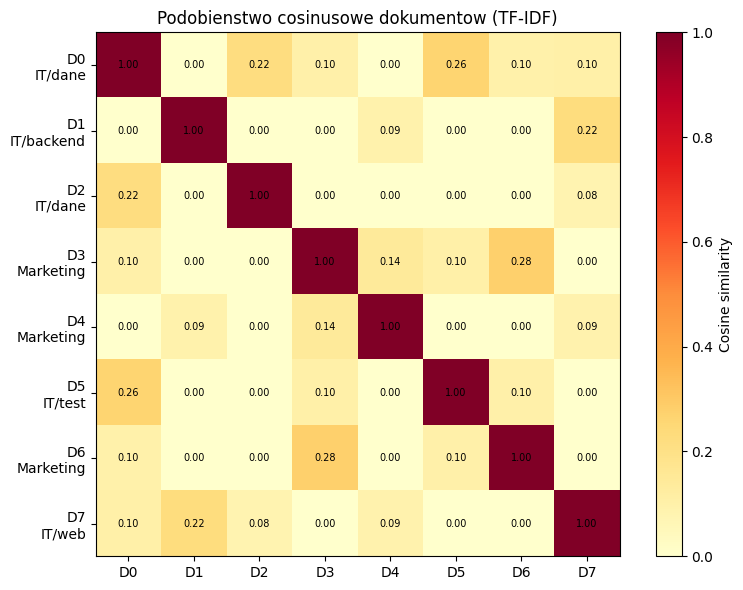

In [9]:
# Wizualizacja heatmap
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cos_sim, cmap="YlOrRd", vmin=0, vmax=1)
ax.set_xticks(range(len(ogloszenia)))
ax.set_yticks(range(len(ogloszenia)))
ax.set_xticklabels([f"D{i}" for i in range(len(ogloszenia))])
ax.set_yticklabels([f"D{i}\n{k}" for i, k in enumerate(kategorie)])
plt.colorbar(im, label="Cosine similarity")
plt.title("Podobienstwo cosinusowe dokumentow (TF-IDF)")

for i in range(len(ogloszenia)):
    for j in range(len(ogloszenia)):
        ax.text(j, i, f"{cos_sim[i,j]:.2f}", ha="center", va="center", fontsize=7)

plt.tight_layout()
plt.show()

### Interpretacja podobienstwa

**Cosine similarity** mierzy kat miedzy wektorami dokumentow (wartosci od 0 do 1):
- **1.0** -- dokumenty identyczne pod wzgledem uzytych slow
- **0.0** -- dokumenty nie maja wspolnych slow

Na co zwrocic uwage:

- **D0 i D2** (oba IT/dane) maja relatywnie wysokie podobienstwo -- oba mowia o `python` i `danych`
- **D3 i D6** (oba Marketing z SEO) -- wykazuja podobienstwo przez `seo` i `doswiadczeniem`
- **D0 i D4** (IT/dane vs Marketing) -- niskie podobienstwo, bo slownik sie nie pokrywa
- Przekatna = 1.0 (dokument jest identyczny z samym soba)

Heatmapa pozwala wizualnie zidentyfikowac **klastry** tematyczne.

### 1.7 Wplyw parametrow na rozmiar macierzy

In [10]:
konfig = [
    {"ngram_range": (1,1), "max_features": None, "min_df": 1},
    {"ngram_range": (1,2), "max_features": None, "min_df": 1},
    {"ngram_range": (1,2), "max_features": 20,   "min_df": 1},
    {"ngram_range": (1,2), "max_features": None, "min_df": 2},
    {"ngram_range": (1,3), "max_features": None, "min_df": 1},
]

print(f"{'n-gram':>10} | {'max_feat':>10} | {'min_df':>6} | {'Cech':>8} | {'Rzadkosc':>10}")
print("-" * 60)

for cfg in konfig:
    vec = TfidfVectorizer(**cfg)
    X = vec.fit_transform(ogloszenia)
    sparsity = 1 - X.nnz / (X.shape[0] * X.shape[1])
    print(f"{str(cfg['ngram_range']):>10} | {str(cfg['max_features']):>10} | "
          f"{cfg['min_df']:>6} | {X.shape[1]:>8} | {sparsity:>10.4f}")

    n-gram |   max_feat | min_df |     Cech |   Rzadkosc
------------------------------------------------------------
    (1, 1) |       None |      1 |       37 |     0.8345
    (1, 2) |       None |      1 |       78 |     0.8558
    (1, 2) |         20 |      1 |       20 |     0.8000
    (1, 2) |       None |      2 |        8 |     0.6875
    (1, 3) |       None |      1 |      111 |     0.8615


### Interpretacja wplywu parametrow

| Parametr | Efekt |
|---|---|
| `ngram_range=(1,2)` vs `(1,1)` | Dodanie bigramow **drastycznie zwieksza** liczbe cech -- kazda para sasiednich slow to nowa cecha |
| `max_features=20` | Twardy limit -- zachowuje tylko 20 najczestszych cech, reszta jest odrzucana |
| `min_df=2` | Odrzuca cechy, ktore pojawily sie w mniej niz 2 dokumentach -- skuteczny filtr szumu |
| `ngram_range=(1,3)` | Trigramy jeszcze bardziej powiekszaja slownik, ale wiekszosc z nich to unikaty |

**Praktyczna regula:** dobry punkt wyjscia to `ngram_range=(1,2)`, `min_df=2-5`, ewentualnie `max_features=5000-20000` dla duzych korpusow.

---
---
## 2. Zadanie do samodzielnej realizacji -- A

### Recenzje ksiazek -- analiza BoW, TF-IDF i podobienstwa

Ponizej masz korpus 12 recenzji ksiazek z dwoch kategorii: **fantasy** i **kryminal**.

**Wykonaj ponizsze kroki:**

1. Zbuduj macierz **Bag-of-Words** (`CountVectorizer`). Wyswietl rozmiar macierzy, rozmiar slownika i gestosc.
2. Zbuduj macierz **TF-IDF** (`TfidfVectorizer`). Wyswietl ja jako DataFrame.
3. Dla kazdego dokumentu wyswietl **top 3 najwazniejsze cechy** (wg TF-IDF).
4. Stworz **ranking globalny termow** (sredni TF-IDF, w ilu dokumentach wystapil). Ktore termy najlepiej odrozniaja kategorie?
5. Oblicz macierz **cosine similarity** i narysuj heatmape. Czy dokumenty z tej samej kategorii sa blizej siebie?
6. Sprawdz, jak zmienia sie liczba cech przy roznych `ngram_range` i `min_df`.

In [11]:
recenzje_ksiazek = [
    # FANTASY
    "Magiczny swiat pelen elfow i smokow, wciagajaca fabula od pierwszej strony",
    "Bohater wyrusza w epicka podroz by pokonac mrocznego wladce",
    "Swietny system magii i budowanie swiata, autor ma niesamowita wyobraznie",
    "Mroczne fantasy z moralnymi dylematami, postacie niejednoznaczne i ciekawe",
    "Piekne opisy krain i stworzen, przypomina najlepsze dziela Tolkiena",
    "Zaklecia i magiczne artefakty tworza fascynujacy element fabuly",

    # KRYMINAL
    "Detektyw prowadzi sledztwo w sprawie zagadkowego morderstwa w zamknietym pokoju",
    "Trzymajacy w napieciu thriller z zaskakujacym zwrotem akcji na koncu",
    "Policjant tropi seryjnego morderce po sladach zostawionych na miejscu zbrodni",
    "Zimny kryminal skandynawski pelen mrocznych tajemnic i zlozonej intrygi",
    "Sledztwo w malym miasteczku odslania mroczne sekrety mieszkancow",
    "Genialny detektyw rozwiazuje sprawe pozornie idealnej zbrodni",
]

kategorie_ksiazek = ["Fantasy"]*6 + ["Kryminal"]*6

print(f"Korpus: {len(recenzje_ksiazek)} dokumentow")
for i, r in enumerate(recenzje_ksiazek):
    print(f"  D{i:2d} [{kategorie_ksiazek[i]:>9s}]: {r}")

Korpus: 12 dokumentow
  D 0 [  Fantasy]: Magiczny swiat pelen elfow i smokow, wciagajaca fabula od pierwszej strony
  D 1 [  Fantasy]: Bohater wyrusza w epicka podroz by pokonac mrocznego wladce
  D 2 [  Fantasy]: Swietny system magii i budowanie swiata, autor ma niesamowita wyobraznie
  D 3 [  Fantasy]: Mroczne fantasy z moralnymi dylematami, postacie niejednoznaczne i ciekawe
  D 4 [  Fantasy]: Piekne opisy krain i stworzen, przypomina najlepsze dziela Tolkiena
  D 5 [  Fantasy]: Zaklecia i magiczne artefakty tworza fascynujacy element fabuly
  D 6 [ Kryminal]: Detektyw prowadzi sledztwo w sprawie zagadkowego morderstwa w zamknietym pokoju
  D 7 [ Kryminal]: Trzymajacy w napieciu thriller z zaskakujacym zwrotem akcji na koncu
  D 8 [ Kryminal]: Policjant tropi seryjnego morderce po sladach zostawionych na miejscu zbrodni
  D 9 [ Kryminal]: Zimny kryminal skandynawski pelen mrocznych tajemnic i zlozonej intrygi
  D10 [ Kryminal]: Sledztwo w malym miasteczku odslania mroczne sekrety mi

In [12]:
# Krok 1: Bag-of-Words
# count_vec = CountVectorizer()
# X_bow = ...
# Wyswietl: rozmiar macierzy, rozmiar slownika, gestosc



In [13]:
# Krok 2: TF-IDF
# tfidf_vec = TfidfVectorizer()
# X_tfidf = ...
# Wyswietl macierz jako DataFrame (transponowana dla czytelnosci: df_tfidf.T)



In [14]:
# Krok 3: Top 3 cechy per dokument
# Wskazowka: dla kazdego wiersza X_tfidf uzyj .argsort()[::-1][:3]



In [15]:
# Krok 4: Ranking globalny termow
# Wskazowka: oblicz freq_dok, freq_total, srednia_tfidf jak w przykladzie



In [16]:
# Krok 5: Cosine similarity + heatmapa
# cos_sim = cosine_similarity(X_tfidf)
# Narysuj heatmape z etykietami kategorii



In [17]:
# Krok 6: Wplyw parametrow
# Przetestuj co najmniej 4 rozne konfiguracje ngram_range, min_df, max_features
# Wyswietl tabele z liczba cech i rzadkoscia



---
---
## 3. Zadanie do samodzielnej realizacji -- B

### Posty z mediow spolecznosciowych -- TF-IDF z bigramami + wyszukiwanie podobnych

Ponizej masz korpus 15 krotkich postow z trzech kategorii: **sport**, **technologia**, **kuchnia**.

**Wykonaj ponizsze kroki:**

1. Zbuduj macierz **TF-IDF z bigramami** (`ngram_range=(1,2)`).
2. Wyswietl **rozmiar macierzy** i porownaj z wariantem tylko unigramowym.
3. Dla kazdego dokumentu wyswietl **top 5 cech** (unigramy i bigramy) -- zwroc uwage, czy bigramy wnosza dodatkowa informacje.
4. Napisz funkcje `znajdz_podobne(query, n=3)`, ktora:
   - Przyjmuje nowy tekst (`query`)
   - Transformuje go za pomoca juz wytrenowanego `tfidf_vec` (metoda `.transform()`)
   - Oblicza cosine similarity z kazdym dokumentem w korpusie
   - Zwraca `n` najbardziej podobnych dokumentow
5. Przetestuj funkcje na co najmniej 3 zapytaniach, np.:
   - `"trening silowy i odzywanie sportowcow"`
   - `"nowy smartfon z aparatem i sztuczna inteligencja"`
   - `"przepis na domowe ciasto drozdzowe"`

In [18]:
posty = [
    # SPORT (0-4)
    "Trening interwalowy to najlepszy sposob na poprawe kondycji biegowej",
    "Reprezentacja zdobyla zloty medal na mistrzostwach swiata w siatkowce",
    "Nowy rekord swiata w maratonie pobity o trzy sekundy",
    "Trener oglosil powolania na zgrupowanie kadry przed meczem",
    "Dieta i regeneracja sa rownie wazne jak sam trening sportowy",

    # TECHNOLOGIA (5-9)
    "Premiera nowego smartfona z aparatem o rozdzielczosci stu megapikseli",
    "Sztuczna inteligencja zmienia sposob w jaki pracujemy i uczymy sie",
    "Aktualizacja systemu operacyjnego przynosi nowe funkcje bezpieczenstwa",
    "Robot wykorzystujacy sztuczna inteligencje pomaga w diagnostyce medycznej",
    "Nowy laptop z procesorem najnowszej generacji i ekranem OLED",

    # KUCHNIA (10-14)
    "Domowy chleb na zakwasie wymaga cierpliwosci ale smakuje wysmienicie",
    "Przepis na szarlotke z kruszonka i cynamonem na jesienne wieczory",
    "Kuchnia azjatycka laczy ostre przyprawy z delikatnymi sosami",
    "Pieczony kurczak z ziolami prowansalskimi i pieczonymi warzywami",
    "Sezon na grzyby to idealny czas na domowy krem z borowikow",
]

kategorie_postow = ["Sport"]*5 + ["Tech"]*5 + ["Kuchnia"]*5

print(f"Korpus: {len(posty)} dokumentow")
for i, p in enumerate(posty):
    print(f"  D{i:2d} [{kategorie_postow[i]:>7s}]: {p}")

Korpus: 15 dokumentow
  D 0 [  Sport]: Trening interwalowy to najlepszy sposob na poprawe kondycji biegowej
  D 1 [  Sport]: Reprezentacja zdobyla zloty medal na mistrzostwach swiata w siatkowce
  D 2 [  Sport]: Nowy rekord swiata w maratonie pobity o trzy sekundy
  D 3 [  Sport]: Trener oglosil powolania na zgrupowanie kadry przed meczem
  D 4 [  Sport]: Dieta i regeneracja sa rownie wazne jak sam trening sportowy
  D 5 [   Tech]: Premiera nowego smartfona z aparatem o rozdzielczosci stu megapikseli
  D 6 [   Tech]: Sztuczna inteligencja zmienia sposob w jaki pracujemy i uczymy sie
  D 7 [   Tech]: Aktualizacja systemu operacyjnego przynosi nowe funkcje bezpieczenstwa
  D 8 [   Tech]: Robot wykorzystujacy sztuczna inteligencje pomaga w diagnostyce medycznej
  D 9 [   Tech]: Nowy laptop z procesorem najnowszej generacji i ekranem OLED
  D10 [Kuchnia]: Domowy chleb na zakwasie wymaga cierpliwosci ale smakuje wysmienicie
  D11 [Kuchnia]: Przepis na szarlotke z kruszonka i cynamonem na je

In [19]:
# Krok 1: TF-IDF z bigramami
# tfidf_vec = TfidfVectorizer(ngram_range=(1, 2))
# X_tfidf = ...



In [20]:
# Krok 2: Porownanie rozmiaru -- unigramy vs unigramy+bigramy
# vec_uni = TfidfVectorizer(ngram_range=(1, 1))
# X_uni = vec_uni.fit_transform(posty)
# Wyswietl: X_uni.shape vs X_tfidf.shape



In [21]:
# Krok 3: Top 5 cech per dokument
# Wskazowka: identycznie jak w przykladzie, ale N=5
# Zwroc uwage na bigramy w wynikach -- czy niosa dodatkowy sens?



In [22]:
# Krok 4: Funkcja znajdz_podobne
# def znajdz_podobne(query, tfidf_vec, X_tfidf, posty, kategorie_postow, n=3):
#     q_vec = tfidf_vec.transform([query])
#     sim = cosine_similarity(q_vec, X_tfidf).flatten()
#     top_idx = sim.argsort()[::-1][:n]
#     ...



In [23]:
# Krok 5: Testy funkcji
# znajdz_podobne("trening silowy i odzywanie sportowcow", ...)
# znajdz_podobne("nowy smartfon z aparatem i sztuczna inteligencja", ...)
# znajdz_podobne("przepis na domowe ciasto drozdzowe", ...)

